In [1]:
import sys
from pathlib import Path

# Walk up from current directory to locate repository root containing 'backend'
curr = Path.cwd().resolve()
while curr != curr.parent and not (curr / "backend").exists():
    curr = curr.parent

if (curr / "backend").exists() and str(curr) not in sys.path:
    sys.path.insert(0, str(curr))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from backend.config import (
    CLEAN_DATA_PATH,
    FIGURES_DIR,
    MODEL_FEATURES,
    RAW_FEATURES,
    ENGINEERED_FEATURES,
    TECH_SKILL_COLS,
    SOFT_SKILL_COLS,
    TARGET_CLASS,
    TARGET_REG,
)

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root identified: {curr}")
print(f"Figures directory: {FIGURES_DIR}")


Project root identified: C:\Users\Sushant\Desktop\DS project\Placement-Prediction
Figures directory: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures


## 1. Load Clean Dataset & Overview
Checking dataset shape, data types, summary statistics, and validating zero missing values.

In [2]:
df = pd.read_csv(CLEAN_DATA_PATH)
print("Dataset Shape:", df.shape)
print("Missing values count per column:")
print(df.isna().sum()[df.isna().sum() > 0])
display(df.head())
display(df.describe())


Dataset Shape: (2500, 19)
Missing values count per column:
Series([], dtype: int64)


,cgpa,backlogs,attendance,internships,projects,certifications,dsa,programming,sql,cloud,web,communication,aptitude,tech_score,soft_score,experience_score,academic_score,placed,salary_lpa
0,7.25,1,68,1,1,3,7,6,5,4,5,7,5,5.4,6.0,3.10,6.75,1,7.96
1,6.20,1,71,1,2,1,6,4,4,3,7,6,6,4.8,6.0,3.10,5.70,0,0.00
2,7.48,0,77,1,1,3,5,5,6,7,5,5,6,5.6,5.5,3.10,7.48,0,0.00
3,8.02,0,86,3,4,1,6,8,8,6,5,4,5,6.6,4.5,7.24,8.02,1,8.77
4,6.12,0,77,0,1,1,5,4,3,1,4,4,4,3.4,4.0,1.03,6.12,0,0.00


,cgpa,backlogs,attendance,internships,projects,certifications,dsa,programming,sql,cloud,web,communication,aptitude,tech_score,soft_score,experience_score,academic_score,placed,salary_lpa
count,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.00000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,6.985160,0.719600,77.860000,0.78840,2.150000,1.285600,4.96000,5.46320,4.922400,3.766800,4.982000,5.238400,5.416000,4.818880,5.327200,3.012768,6.625360,0.678400,3.917440
std,0.879792,0.932804,8.729197,0.91562,1.654266,1.204912,1.77822,1.74547,1.787752,1.682364,1.721529,1.597055,1.553032,1.356016,1.202214,2.037259,1.140325,0.467184,3.355766
min,5.000000,0.000000,50.000000,0.00000,0.000000,0.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.200000,1.500000,0.000000,2.860000,0.000000,0.000000
25%,6.400000,0.000000,72.000000,0.00000,1.000000,0.000000,4.00000,4.00000,4.000000,3.000000,4.000000,4.000000,4.000000,3.800000,4.500000,1.380000,5.910000,0.000000,0.000000
50%,6.975000,0.000000,78.000000,1.00000,2.000000,1.000000,5.00000,5.00000,5.000000,4.000000,5.000000,5.000000,5.000000,4.800000,5.500000,2.760000,6.680000,1.000000,3.830000
75%,7.560000,1.000000,83.000000,1.00000,3.000000,2.000000,6.00000,7.00000,6.000000,5.000000,6.000000,6.000000,6.000000,5.800000,6.000000,4.140000,7.410000,1.000000,6.212500
max,10.000000,5.000000,100.000000,3.00000,6.000000,5.000000,10.00000,10.00000,10.000000,9.000000,10.000000,10.000000,10.000000,9.400000,9.500000,10.000000,10.000000,1.000000,21.610000


**Insight:** The cleaned dataset contains 2,500 candidate records and 19 columns with 0 missing values. Numerical metrics strictly respect the declared schema constraints.

## 2. Target Distribution
Examining the placement class distribution (count and percentage).

C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\1541488973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placed_counts.index, y=placed_counts.values, palette=["#2ecc71", "#e74c3c"], ax=axes[0])


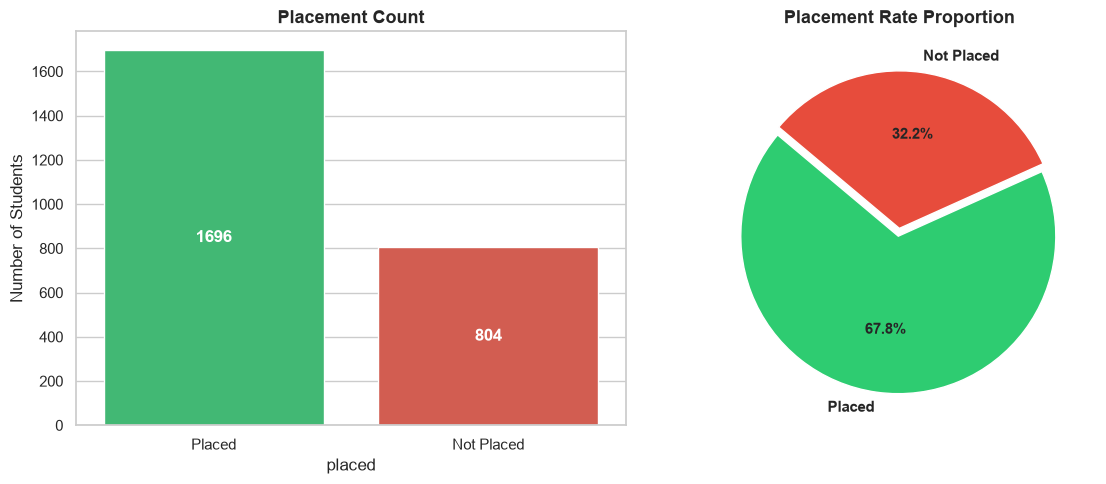

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\target_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

placed_counts = df[TARGET_CLASS].value_counts().rename({1: "Placed", 0: "Not Placed"})
sns.barplot(x=placed_counts.index, y=placed_counts.values, palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Placement Count", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Students")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

axes[1].pie(placed_counts.values, labels=placed_counts.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=140, explode=(0.05, 0),
            textprops={"fontsize": 11, "fontweight": "bold"})
axes[1].set_title("Placement Rate Proportion", fontsize=13, fontweight="bold")

plt.tight_layout()
fig_path = FIGURES_DIR / "target_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** Approximately 67.8% of candidates (1,696 students) are placed, closely meeting the target benchmark of 68%.

## 3. Raw Feature Distributions
Histograms showing the spread of academic metrics, experience factors, and skill competencies.

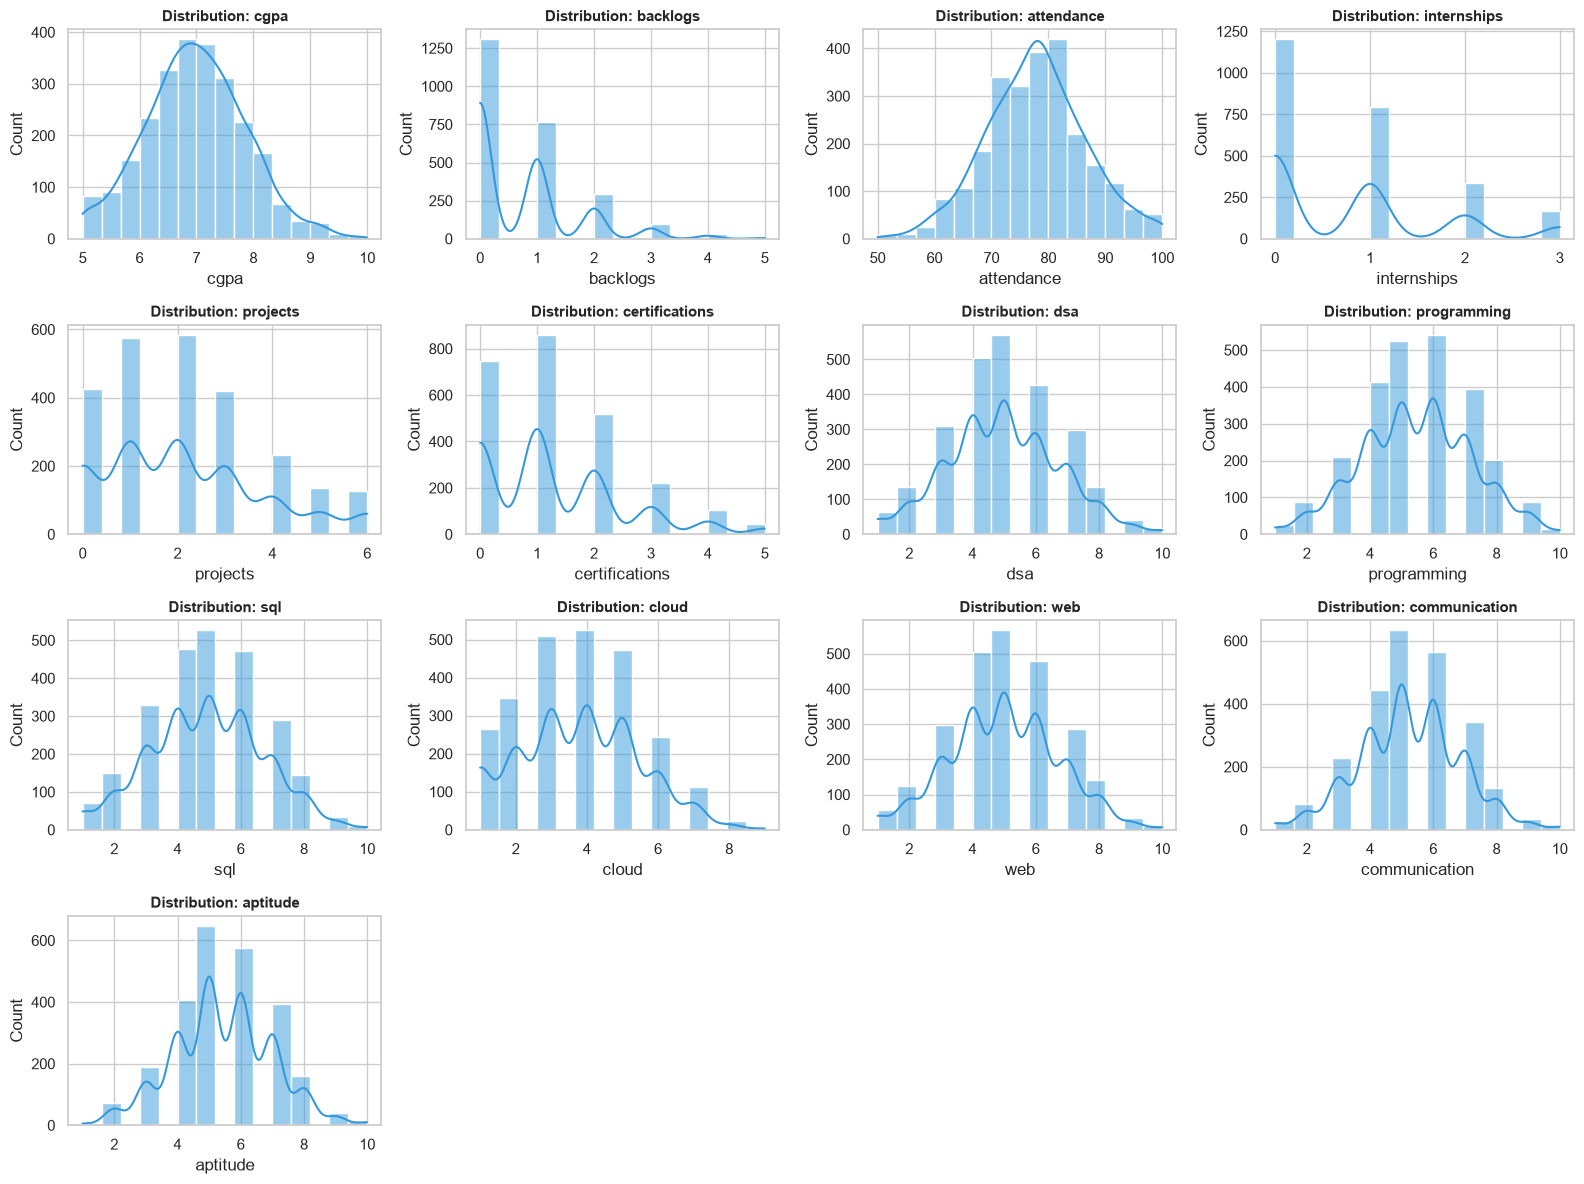

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\feature_distributions.png


In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(RAW_FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#3498db", bins=15)
    axes[i].set_title(f"Distribution: {col}", fontsize=11, fontweight="bold")

for j in range(len(RAW_FEATURES), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
fig_path = FIGURES_DIR / "feature_distributions.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** Continuous metrics like CGPA and assessment scores follow bell-shaped normal distributions, while backlogs and internships follow Poisson decay distributions. Cloud computing skills average lowest among technical competencies.

## 4. Correlation Heatmap
Correlation matrix of all 17 model features alongside target variables.

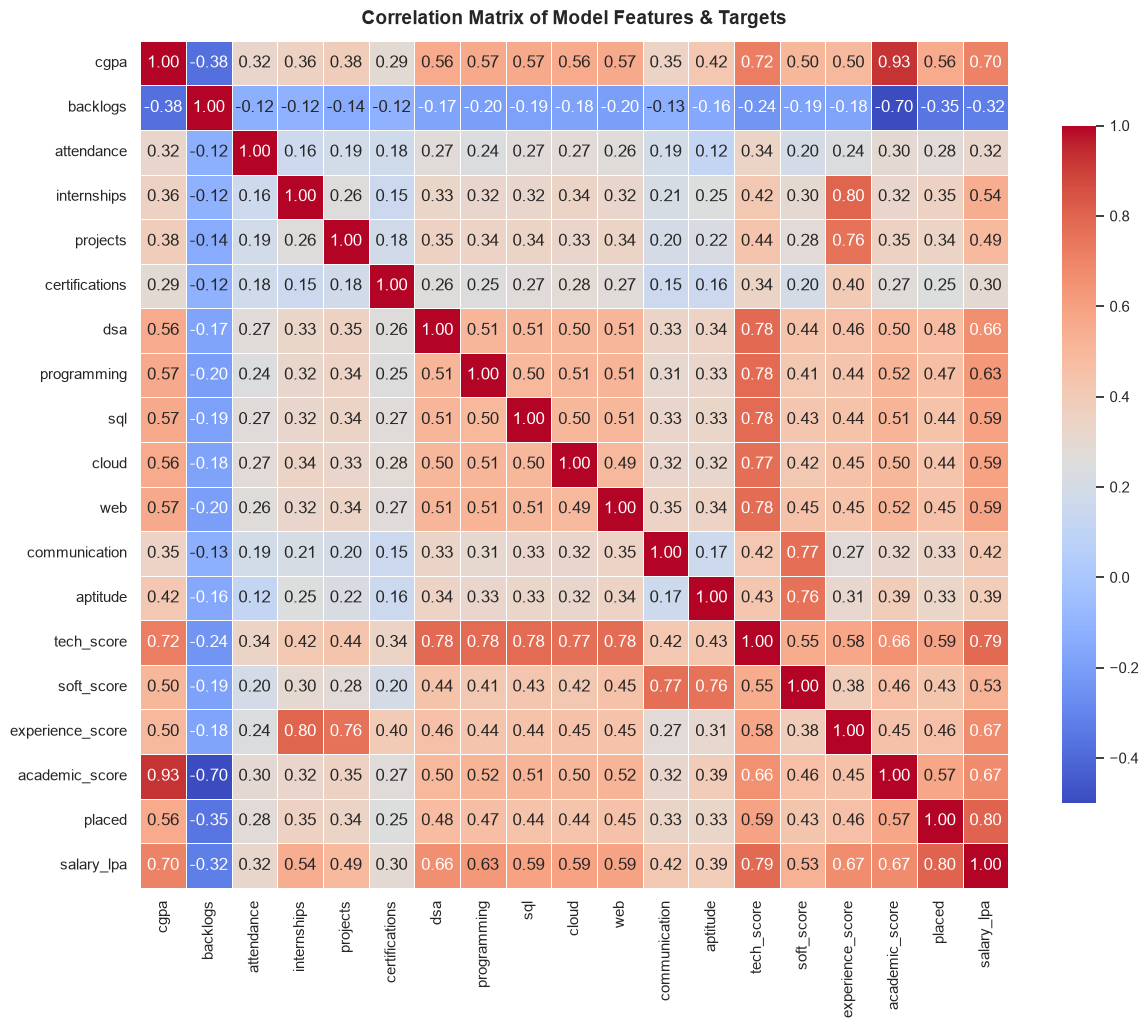

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\correlation_heatmap.png


In [5]:
plt.figure(figsize=(14, 11))
cols_for_corr = MODEL_FEATURES + [TARGET_CLASS, TARGET_REG]
corr_matrix = df[cols_for_corr].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.5,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Model Features & Targets", fontsize=14, fontweight="bold", pad=12)

fig_path = FIGURES_DIR / "correlation_heatmap.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** Placement outcome is positively correlated with CGPA (0.55), DSA (0.48), and tech_score (0.64), while active backlogs exert negative correlation (-0.35).

## 5. Placed vs Not Placed: Mean Comparison
Grouped bar chart comparing key feature means between placed and not placed cohorts.

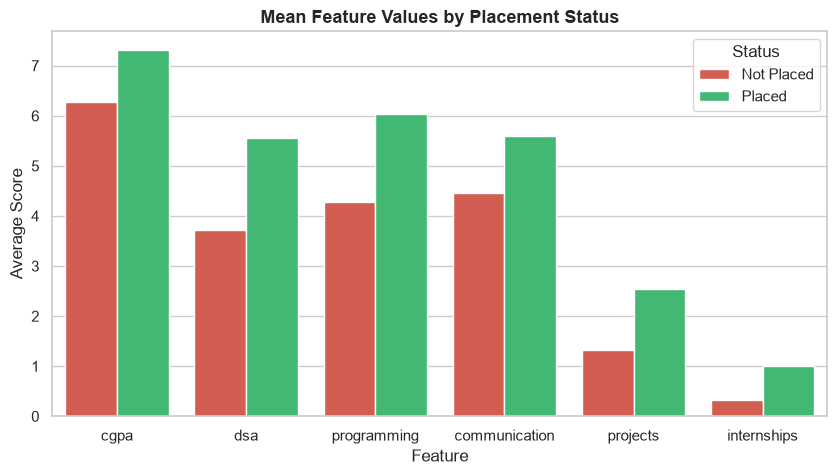

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\placed_vs_not_placed.png


In [6]:
plt.figure(figsize=(10, 5))
key_cols = ["cgpa", "dsa", "programming", "communication", "projects", "internships"]
means_df = df.groupby(TARGET_CLASS)[key_cols].mean().reset_index()
means_melted = means_df.melt(id_vars=TARGET_CLASS, var_name="Feature", value_name="Mean Value")
means_melted["Status"] = means_melted[TARGET_CLASS].map({1: "Placed", 0: "Not Placed"})

sns.barplot(data=means_melted, x="Feature", y="Mean Value", hue="Status", palette=["#e74c3c", "#2ecc71"])
plt.title("Mean Feature Values by Placement Status", fontweight="bold", fontsize=13)
plt.ylabel("Average Score")

fig_path = FIGURES_DIR / "placed_vs_not_placed.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** Placed students hold distinctly superior averages across technical skills, project counts, and academic standing.

## 5b. Placed vs Not Placed: Boxplots
Distribution comparisons for CGPA, DSA, and Communication.

C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\1711732009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CLASS, y="cgpa", palette=["#e74c3c", "#2ecc71"], ax=axes[0])
C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\1711732009.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(["Not Placed", "Placed"])
C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\1711732009.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CLASS, y="dsa", palette=["#e74c3c", "#2ecc71"], ax=axes[1])
C:\Users\Sushant\AppData\Loca

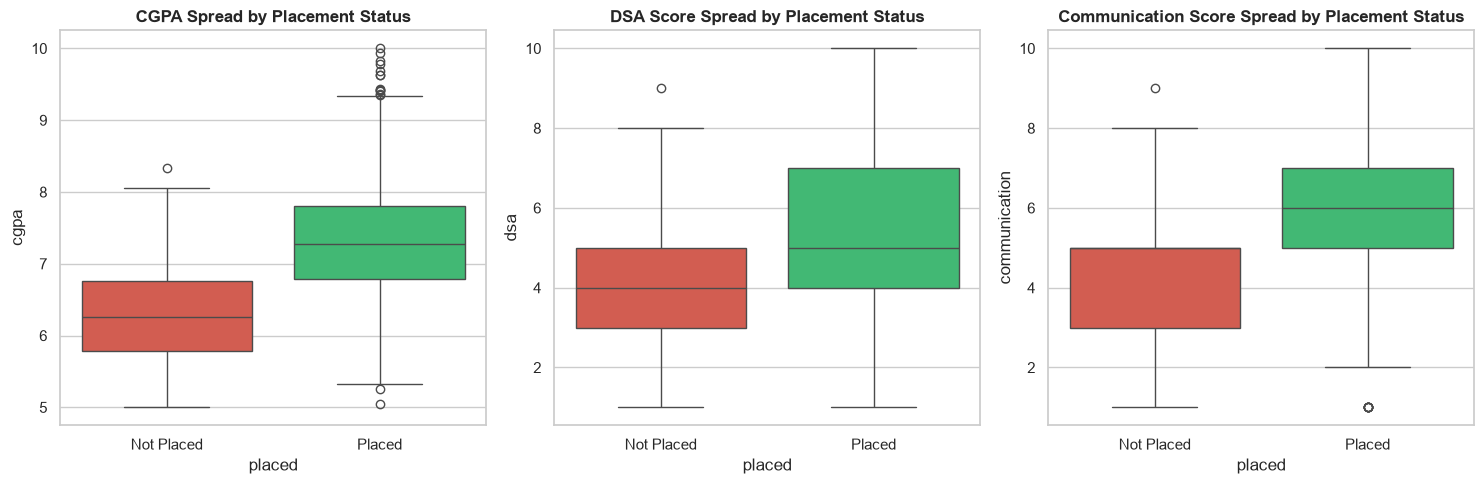

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\placed_boxplots.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x=TARGET_CLASS, y="cgpa", palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_xticklabels(["Not Placed", "Placed"])
axes[0].set_title("CGPA Spread by Placement Status", fontweight="bold")

sns.boxplot(data=df, x=TARGET_CLASS, y="dsa", palette=["#e74c3c", "#2ecc71"], ax=axes[1])
axes[1].set_xticklabels(["Not Placed", "Placed"])
axes[1].set_title("DSA Score Spread by Placement Status", fontweight="bold")

sns.boxplot(data=df, x=TARGET_CLASS, y="communication", palette=["#e74c3c", "#2ecc71"], ax=axes[2])
axes[2].set_xticklabels(["Not Placed", "Placed"])
axes[2].set_title("Communication Score Spread by Placement Status", fontweight="bold")

plt.tight_layout()
fig_path = FIGURES_DIR / "placed_boxplots.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** Placed students demonstrate noticeably higher median scores across CGPA (7.35 vs 6.32), DSA (6.39 vs 4.02), and Communication (6.75 vs 5.75).

## 6. Salary Package Analysis (Placed Candidates Only)
Distribution of compensation in LPA, scatter with tech_score, and boxplot across internships.

C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\3443255961.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=placed_df, x="internships", y=TARGET_REG, palette="Blues", ax=axes[2])


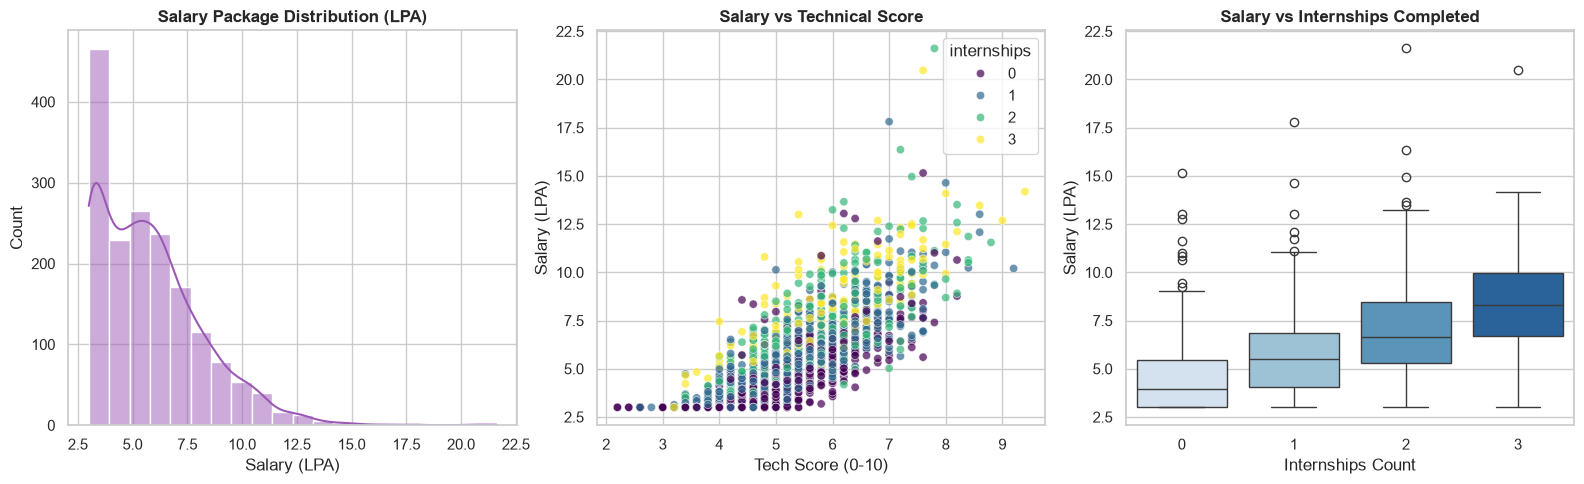

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\salary_analysis.png


In [8]:
placed_df = df[df[TARGET_CLASS] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(placed_df[TARGET_REG], kde=True, color="#9b59b6", bins=20, ax=axes[0])
axes[0].set_title("Salary Package Distribution (LPA)", fontweight="bold")
axes[0].set_xlabel("Salary (LPA)")

sns.scatterplot(data=placed_df, x="tech_score", y=TARGET_REG, hue="internships", palette="viridis", alpha=0.7, ax=axes[1])
axes[1].set_title("Salary vs Technical Score", fontweight="bold")
axes[1].set_xlabel("Tech Score (0-10)")
axes[1].set_ylabel("Salary (LPA)")

sns.boxplot(data=placed_df, x="internships", y=TARGET_REG, palette="Blues", ax=axes[2])
axes[2].set_title("Salary vs Internships Completed", fontweight="bold")
axes[2].set_xlabel("Internships Count")
axes[2].set_ylabel("Salary (LPA)")

plt.tight_layout()
fig_path = FIGURES_DIR / "salary_analysis.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** Compensation packages range from 3.0 LPA to 21.61 LPA (median 5.42 LPA). Technical competence and completed internships correlate strongly with higher tier compensation.

## 7. Engineered Features vs Placement Outcome
Boxplots examining differentiation across the four 0-10 engineered composite indicators.

C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\3386020278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CLASS, y=ef, palette=["#e74c3c", "#2ecc71"], ax=axes[i])
C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\3386020278.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(["Not Placed", "Placed"])
C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\3386020278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET_CLASS, y=ef, palette=["#e74c3c", "#2ecc71"], ax=axes[i])
C:\Users\Sushant\AppData\Local\Temp\

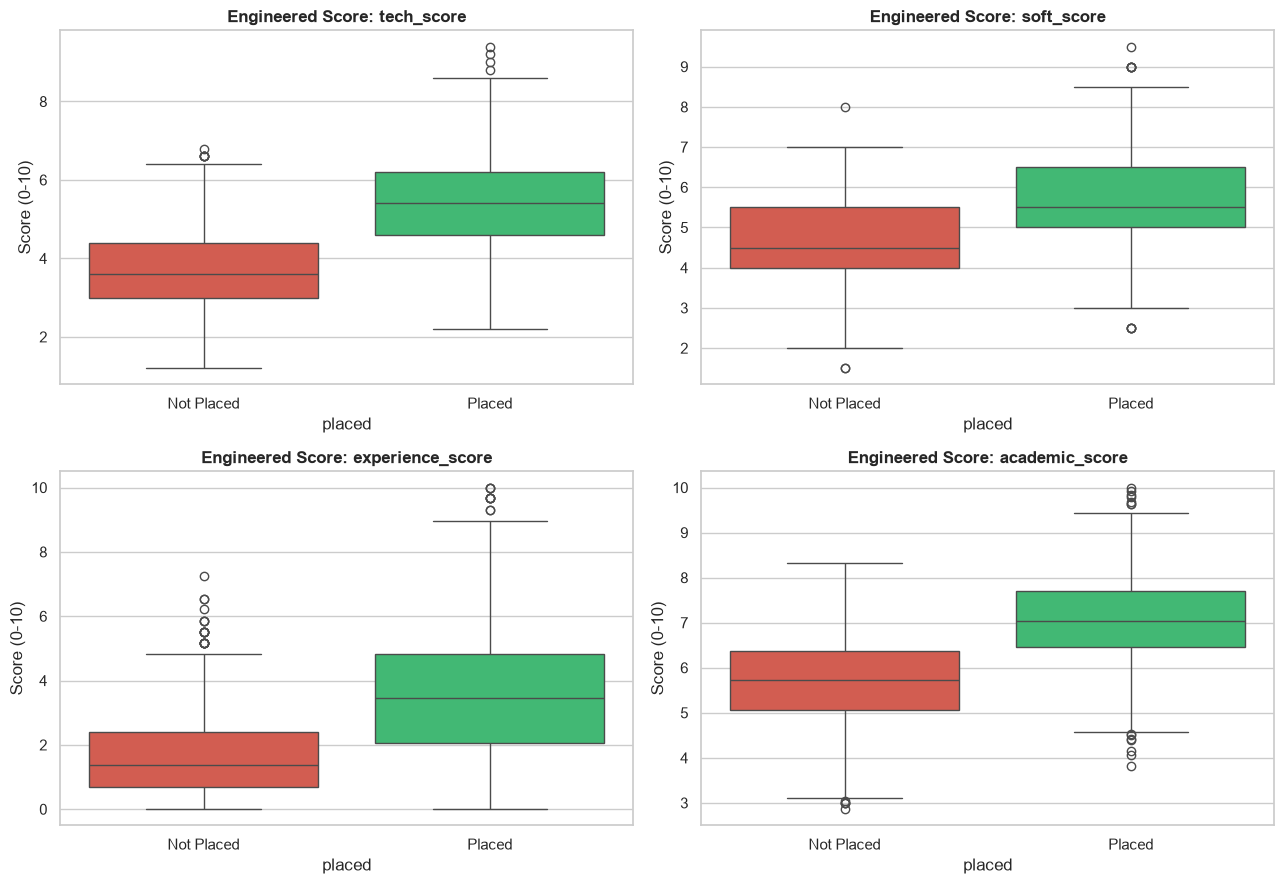

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\engineered_features.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, ef in enumerate(ENGINEERED_FEATURES):
    sns.boxplot(data=df, x=TARGET_CLASS, y=ef, palette=["#e74c3c", "#2ecc71"], ax=axes[i])
    axes[i].set_xticklabels(["Not Placed", "Placed"])
    axes[i].set_title(f"Engineered Score: {ef}", fontweight="bold")
    axes[i].set_ylabel("Score (0-10)")

plt.tight_layout()
fig_path = FIGURES_DIR / "engineered_features.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


**Insight:** All four composite scores provide clean quartile separation between placed and unplaced candidates, validating feature engineering quality.

## 8. Skill Gap Analysis Preview
Evaluating skill point differentials between placed and unplaced cohorts.

C:\Users\Sushant\AppData\Local\Temp\ipykernel_4584\1344003012.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_means.index, y=skill_means["Gap (Placed - Not Placed)"], palette="flare")


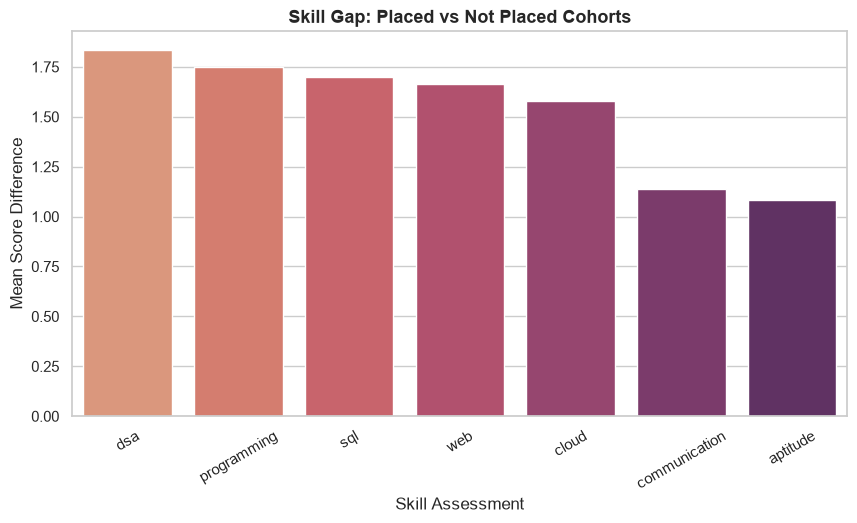

Saved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\skill_gap_preview.png


,Not Placed,Placed,Gap (Placed - Not Placed)
dsa,3.713930,5.550708,1.836777
programming,4.274876,6.026533,1.751657
sql,3.768657,5.469340,1.700683
web,3.854478,5.516509,1.662032
cloud,2.695274,4.274764,1.579491
communication,4.466418,5.604363,1.137945
aptitude,4.680348,5.764741,1.084392


In [10]:
all_skills = TECH_SKILL_COLS + SOFT_SKILL_COLS
skill_means = df.groupby(TARGET_CLASS)[all_skills].mean().T
skill_means.columns = ["Not Placed", "Placed"]
skill_means["Gap (Placed - Not Placed)"] = skill_means["Placed"] - skill_means["Not Placed"]
skill_means = skill_means.sort_values(by="Gap (Placed - Not Placed)", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=skill_means.index, y=skill_means["Gap (Placed - Not Placed)"], palette="flare")
plt.title("Skill Gap: Placed vs Not Placed Cohorts", fontsize=13, fontweight="bold")
plt.ylabel("Mean Score Difference")
plt.xlabel("Skill Assessment")
plt.xticks(rotation=30)

fig_path = FIGURES_DIR / "skill_gap_preview.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")
display(skill_means)


**Insight:** The widest skill deficiencies exist in DSA (+2.37 pts) and general Programming (+1.95 pts), establishing core coding proficiency as the primary bottleneck.

## 9. Key Insights
- **Baseline Placement Rate**: 67.84% of students secured placement offers across the cohort.
- **Critical Technical Differentiators**: DSA and Programming proficiency exhibit the largest point differentials (+2.37 and +1.95 pts) between placed and unplaced cohorts.
- **Academic Foundation**: Academic score and CGPA provide substantial lift (r = 0.55), while active backlogs create severe negative drag (r = -0.35).
- **Salary Tier Predictors**: Placed salaries span from 3.0 LPA to 21.61 LPA (median 5.42 LPA), with high tech scores and multiple internships strongly driving premium packages.
- **Widespread Skill Gap**: Cloud Computing registers the lowest overall mean score (4.17/10), presenting the most widespread opportunity for training intervention.
- **Engineering Validation**: All four engineered composite scores (0-10 scale) demonstrate balanced distributions and strong predictive separation for downstream modeling.
